# Diabetic retinopathy stage detection

Computer Vision coursework 1, BSc (Hons) Computer Science, NIBM.

A convolutional neural network with transfer learning grades retinal fundus
photographs on the five-stage clinical scale, and is tested at four hospitals
in three countries, two of which it never saw during training.

| Grade | Stage | What a clinician sees |
|---|---|---|
| 0 | No DR | healthy retina |
| 1 | Mild | a few microaneurysms (tiny red dots) |
| 2 | Moderate | more microaneurysms, small haemorrhages, hard exudates |
| 3 | Severe | widespread haemorrhages, venous beading |
| 4 | Proliferative | new fragile vessels, risk of bleeding and blindness |

**How this notebook works.** Training takes hours, so it is done from the
command line and saved to `runs/`. This notebook reads those saved results and
regenerates every figure and table. Running it top to bottom takes about 15
minutes and trains nothing.

| Step | Command |
|---|---|
| Normalise each Kaggle download | `python prepare_data.py --root <folder> --out data/raw/<name>` |
| Find duplicates in all datasets | `python dedup.py aptos ddr idrid messidor` |
| Clean, split, preprocess | `python pipeline_v2.py clean`, `split`, `cache v3`, `cache v4` |
| Train one experiment | `python pipeline_v2.py train <run name>` |
| Score every run on every hospital | `python pipeline_v2.py evaluate` |
| Final-model evidence | `python final_report.py` |
| Prototype | `python app.py` |


In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from PIL import Image as PILImage

from dr import CLASSES
from dr import data as D
from dr import evaluate as E
from dr import preprocess as P
from dr.model import build_model, freeze_backbone, unfreeze_top, param_counts
import pipeline_v2 as PV
%matplotlib inline
# pipeline_v2 selects matplotlib's file-only backend for its own scripts; switch back to inline charts.

pd.set_option("display.width", 140)
DATASETS = ["aptos", "ddr", "idrid", "messidor"]
LABEL = {"aptos": "APTOS 2019 (India)", "ddr": "DDR (China)",
         "idrid": "IDRiD (India, other hospital)", "messidor": "Messidor-2 (France)"}
RAW = {n: Path(f"data/raw/{n}") for n in DATASETS}
RAW_IMG = {n: {p.stem: p for p in (RAW[n] / "all_images").iterdir()} for n in DATASETS}
RUNS, FINAL = Path("runs/v2"), Path("runs/final")
print("device:", E.get_device())


device: mps


## 1. Problem and datasets

Diabetic retinopathy is damage to the retina's small blood vessels caused by
diabetes, and a leading cause of preventable blindness in working-age adults.
Early stages have no symptoms but are treatable, so people with diabetes are
screened with fundus photographs. There are far more patients than trained
graders, which is the case for automated grading.

**Four public Kaggle datasets, each with a fixed role.** The roles never change,
so no score is ever measured on photos a model trained on.

| Dataset | Origin | Photos | Graded by | Role |
|---|---|---|---|---|
| APTOS 2019 | Aravind Eye Hospital, rural India | 3,662 | clinicians, one per photo | train / validate / test |
| DDR | 147 hospitals, 23 provinces, China | 12,522 | seven trained graders | train / validate / test (pooled model only) |
| IDRiD | one eye clinic, Nanded, India | 455 | retina specialists | **test only, never trained on** |
| Messidor-2 | France | 1,744 | three retina specialists, adjudicated | **test only, never trained on** |

**Why APTOS as the main dataset.** Real clinical photographs, raw so the
preprocessing is our own work, the most benchmarked DR dataset (published
kappa range 0.85 to 0.92), and small enough to train on a laptop GPU.
Pre-processed or pre-balanced Kaggle derivatives were rejected because they do
the graded preprocessing work for you.

**Ethics.** All four datasets are de-identified and released for research.
Messidor-2 images are distributed by ADCIS under a registration agreement; the
Kaggle copy is a third-party mirror. This is a coursework prototype, not a
medical device.


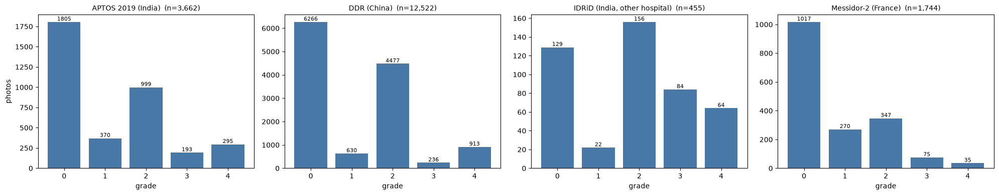

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, n in zip(axes, DATASETS):
    counts = pd.read_csv(RAW[n] / "train.csv")["diagnosis"].value_counts().reindex(range(5), fill_value=0)
    bars = ax.bar([str(i) for i in range(5)], counts.values, color="#4878A8")
    ax.bar_label(bars, fmt="%d", fontsize=8)
    ax.set_title(f"{LABEL[n]}  (n={counts.sum():,})", fontsize=10)
    ax.set_xlabel("grade")
axes[0].set_ylabel("photos")
plt.tight_layout(); plt.savefig("runs/class_distribution_all.png", dpi=130, bbox_inches="tight"); plt.show()
# Every dataset is dominated by grade 0; grades 1 and 3 are rare everywhere.


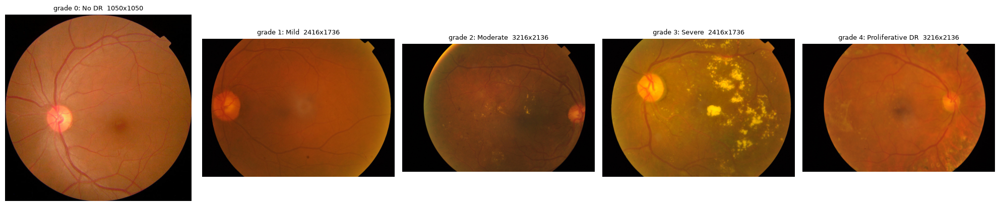

In [3]:
aptos = pd.read_csv(RAW["aptos"] / "train.csv").astype({"id_code": str})
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for g, ax in enumerate(axes):
    sid = aptos[aptos.diagnosis == g].id_code.iloc[0]
    img = P.read_rgb(RAW_IMG["aptos"][sid])
    ax.imshow(img); ax.axis("off"); ax.set_title(f"grade {g}: {CLASSES[g]}  {img.shape[1]}x{img.shape[0]}", fontsize=9)
plt.tight_layout(); plt.show()
# Sizes, framing and colour all vary with the camera: the preprocessing has to remove that.


## 2. Data quality: duplicates and contradictory labels

Public DR datasets contain repeated photographs. Three detectors were used
(`dedup.py`), from strict to loose:

1. **Exact copies**: identical file hash.
2. **Candidates**: perceptual hash of the photo, or cosine similarity of CNN features.
3. **Verification**: every candidate is checked by correlating the high-pass
   vessel pattern of the two raw photos inside the retina. Perceptual hashes
   alone over-flag fundus photos badly, because every photo shares the same
   bright disc and dark rim; the vessel tree is unique to each eye. Exact copies
   score 1.0 and unrelated eyes at most about 0.5, so a threshold of 0.6-0.67
   separates them.

**Cleaning rule:** keep one photo per duplicate group, and remove **every copy**
of a group whose copies carry different grades. Nobody knows which grade is
right, and such photos teach the model two answers for one picture.


In [4]:
display(pd.read_csv("data/clean/summary.csv"))
pairs = pd.read_csv("runs/dedup/pairs_aptos_ddr_idrid_messidor.csv")
print(f"verified duplicate pairs: {len(pairs)} ({pairs.exact.sum()} exact, {(~pairs.exact).sum()} near-duplicates)")
print(f"pairs with conflicting grades: {(pairs.grade_a != pairs.grade_b).sum()}")
print(f"pairs across two different datasets: {(pairs.dataset_a != pairs.dataset_b).sum()}")


,dataset,raw,in duplicate groups,dropped (conflicting grades),dropped (extra copies),clean
0,aptos,3662,416,79,228,3355
1,ddr,12522,305,6,154,12362
2,idrid,455,12,6,3,446
3,messidor,1744,22,8,7,1729


verified duplicate pairs: 609 (245 exact, 364 near-duplicates)
pairs with conflicting grades: 53
pairs across two different datasets: 0


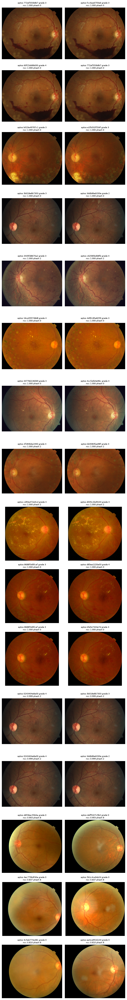

In [5]:
display(Image("runs/dedup/near_duplicates_aptos.png", width=420))
# Verified near-duplicates: the same eye re-saved or re-cropped, several graded differently.


Identical pixels carrying two different grades are direct evidence of grader
disagreement, and they cap what any model can reach. No photo is shared between
datasets, so IDRiD and Messidor-2 are genuinely unseen.


## 3. Train, validation and test splits

APTOS and DDR are each split once, **stratified 70 / 15 / 15** so every split
keeps the same grade mix, and written to disk so every experiment uses the same
photos. Validation photos decide when to stop and which version to keep; test
photos are opened only for the final scores. IDRiD and Messidor-2 are used whole
as test sets.


In [6]:
for n in ("aptos", "ddr"):
    s = {k: pd.read_csv(PV.SPLITS / n / f"{k}.csv") for k in ("train", "val", "test")}
    print(LABEL[n]); display(D.split_summary(s))
for n in ("idrid", "messidor"):
    t = pd.read_csv(PV.SPLITS / n / "test.csv")
    print(f"{LABEL[n]}: {len(t)} test photos, grades {t.diagnosis.value_counts().sort_index().tolist()}")


APTOS 2019 (India)


,train,val,test
0 No DR,1165,250,250
1 Mild,236,51,51
2 Moderate,645,138,138
3 Severe,117,25,25
4 Proliferative DR,184,40,40
total,2347,504,504


DDR (China)


,train,val,test
0 No DR,4286,919,919
1 Mild,439,94,94
2 Moderate,3127,670,671
3 Severe,165,36,35
4 Proliferative DR,635,136,136
total,8652,1855,1855


IDRiD (India, other hospital): 446 test photos, grades [128, 20, 153, 83, 62]
Messidor-2 (France): 1729 test photos, grades [1013, 264, 342, 75, 35]


## 4. Preprocessing

### 4a. The classic enhancement chain (v1)

The first pipeline followed the textbook recipe from the 2015 Kaggle DR
competition winner: crop the black border, resize, **Ben Graham blur-subtraction**
(subtract a Gaussian-blurred copy, which evens out illumination and enhances
edges), **CLAHE on the green channel** (local contrast enhancement; blood absorbs
green light) and a **3x3 median blur** (noise removal).


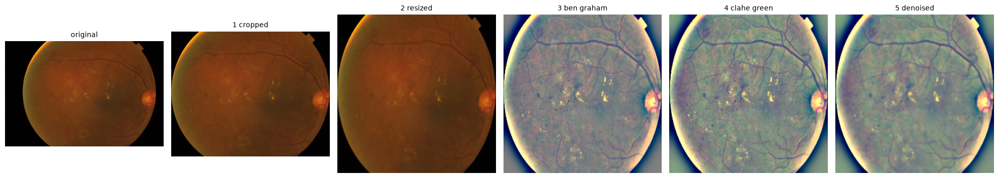

In [7]:
sid = aptos[aptos.diagnosis == 2].id_code.iloc[0]
stages = P.steps(P.read_rgb(RAW_IMG["aptos"][sid]))
fig, axes = plt.subplots(1, len(stages), figsize=(20, 4))
for ax, (name, img) in zip(axes, stages.items()):
    ax.imshow(img); ax.set_title(name, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.savefig("runs/preprocessing_steps_v1.png", dpi=130, bbox_inches="tight"); plt.show()


### 4b. What the evidence says

A literature review before rebuilding the pipeline found:

| Step | Evidence |
|---|---|
| Resolution | Largest single lever. ResNet-50 on EyePACS: 256 px 0.744, 512 px 0.803 kappa (Huang et al. 2021). A microaneurysm "may occupy only 1 pixel or less" at 299 px (Krause et al. 2018) |
| Ben Graham, CLAHE | With ImageNet-pretrained CNNs: -0.5 and -0.7 kappa (Huang et al. 2021). The 4th-place APTOS team dropped Ben Graham as it "didn't boost score" |
| Median blur | No supporting study. By design it removes isolated 1-3 px features, the size of a microaneurysm (our inference, not a measured result) |
| Augmentation | Stronger colour jitter plus simulated camera artefacts gave most of the gain on unseen hospitals in the GDRBench benchmark (Che et al. 2023) |

So v2 dropped the enhancement and went to 512 px. The ablation in section 8
tests each change on our own data.

### 4c. A shortcut: the photo's outline predicted the grade

APTOS photos come from cameras with different fields of view, and the cameras
were used on different patients.


In [8]:
def outline(path):
    c = P.crop_circle(P.read_rgb(path)); g = cv2.cvtColor(c, cv2.COLOR_RGB2GRAY) > 7
    h, w = g.shape; k = max(2, int(0.04 * min(h, w)))
    corners = np.mean([g[:k, :k].mean(), g[:k, -k:].mean(), g[-k:, :k].mean(), g[-k:, -k:].mean()])
    return "fills the frame" if corners > 0.5 else ("flat-cut" if h / w < 0.9 else "full circle")

tr = pd.read_csv(PV.SPLITS / "aptos" / "train.csv").astype({"id_code": str})
tr["outline"] = [outline(RAW_IMG["aptos"][i]) for i in tr.id_code]
t = pd.crosstab(tr.outline, tr.diagnosis)
t["photos"] = t.sum(axis=1); t["% healthy"] = (t[0] / t["photos"] * 100).round(1)
t


diagnosis,0,1,2,3,4,photos,% healthy
outline,,,,,,,
fills the frame,77,4,14,1,2,98,78.6
flat-cut,235,219,602,116,175,1347,17.4
full circle,853,13,29,0,7,902,94.6


**About 95 % of full-circle photos are healthy, against about 17-22 % of flat-cut
ones**, and every IDRiD photo is flat-cut. A model can therefore learn "round
means healthy" without looking at the retina.

**Causal test** (181 healthy full-circle APTOS test photos): the top and bottom
of each photo were blacked out and nothing else changed.

| Model | Average drop in P(healthy) | Healthy photos flipped to "diseased" |
|---|---|---|
| v1 pipeline | 0.10 | 1 % |
| v2 pipeline, APTOS only | 0.30 | 2 % |
| v2 pipeline, APTOS + DDR | 0.18 | 9 % |

The models were using the outline. v2's padding preserved the exact outline and
made the shortcut easier than v1's stretching had. It also explains why every
v2 model over-called healthy IDRiD eyes.

### 4d. Final pipelines: every photo gets the same outline

**v3**: crop the border, **cut every photo to the same band** (height 0.70 x
width, just flatter than the flattest natural cut in 95 % of photos across all
four datasets), pad to a square, resize to 512. No enhancement.

**v4**: v3, plus trimming to the inscribed circle (for the ~4 % of photos framed
to their corners), plus the brief's **edge enhancement** (Ben Graham, sigma =
radius/30 as in the original method) and **contrast enhancement** (CLAHE on
green), and a re-mask of the rim. No median blur.


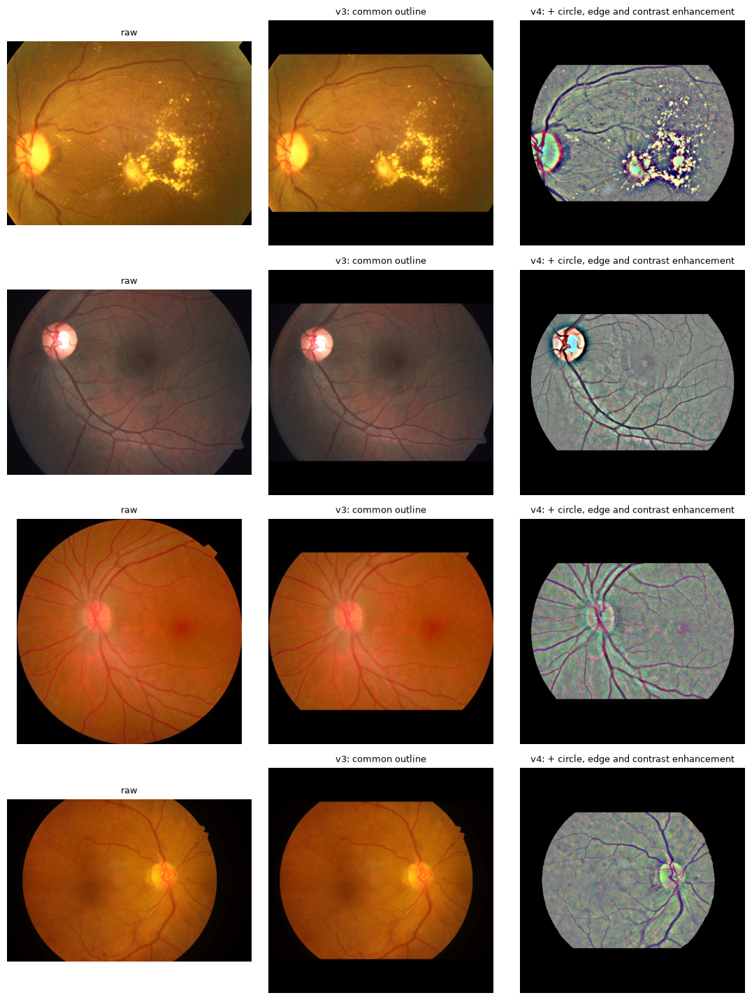

In [9]:
examples = [RAW_IMG["aptos"][i] for i in tr.groupby("outline").head(1).id_code] + [next(iter(RAW_IMG["idrid"].values()))]
fig, axes = plt.subplots(len(examples), 3, figsize=(11, 3.6 * len(examples)))
for r, path in enumerate(examples):
    img = P.read_rgb(path)
    for c, (title, im) in enumerate([("raw", img), ("v3: common outline", P.preprocess_v3(img)),
                                     ("v4: + circle, edge and contrast enhancement", P.preprocess_v4(img))]):
        axes[r, c].imshow(im); axes[r, c].axis("off"); axes[r, c].set_title(title, fontsize=9)
plt.tight_layout(); plt.savefig("runs/preprocessing_v3_v4.png", dpi=110, bbox_inches="tight"); plt.show()
# Whatever the camera, every photo leaves preprocessing with the same outline.


## 5. Augmentation and class balance

**Augmentation** (training photos only, a new random draw every epoch). A retina
is the same retina rotated or mirrored, so the grade never changes.

| Transform | Setting | Why |
|---|---|---|
| Random resized crop | 448 px from 512, scale 0.8-1.0 | mild zoom; never crops a lesion out |
| Horizontal and vertical flip, rotation | up to 180 degrees | cameras are hand-held; orientation carries no information |
| Colour jitter | brightness, contrast, saturation 0.4, hue 0.05 | cameras render colour differently; hue kept small |
| Camera artefacts | halo, dark patch, bright spots, p=0.5 each | after GDRNet's FundusAug: lighting flaws are not disease |
| Blur and sharpness | Gaussian sigma 0.1-3, sharpness x2, p=0.5 | focus varies between clinics |

Validation and test photos are only resized.

**Class balance.** Grade 0 is about half of APTOS and grade 3 about 5 %. A model
that always answers "No DR" scores about 50 % accuracy and is useless.
A **weighted sampler** draws rare grades more often. When APTOS and DDR are pooled,
77 % of every grade comes from DDR, so the sampler balances over (dataset, grade)
pairs with soft weights 1/count^0.5 (after GDRNet's DCR). Class weights in the
loss were tried as the alternative and were worse (section 8a).


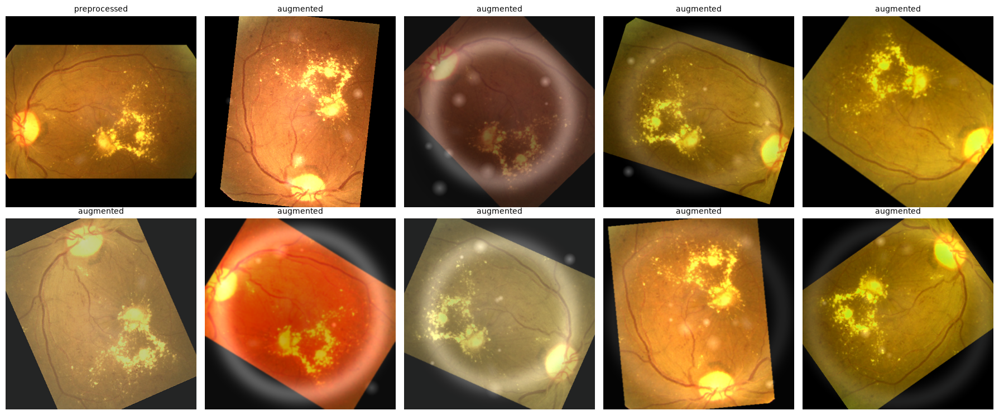

In [10]:
img = PILImage.open(PV.CACHE_V3 / f"{tr.id_code.iloc[0]}.png").convert("RGB")
tfm = D.train_tfms_v2(448)
mean, std = torch.tensor(D.IMAGENET_MEAN).view(3, 1, 1), torch.tensor(D.IMAGENET_STD).view(3, 1, 1)
fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
axes[0, 0].imshow(img); axes[0, 0].set_title("preprocessed", fontsize=10); axes[0, 0].axis("off")
for ax in list(axes.flat)[1:]:
    ax.imshow((tfm(img) * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()); ax.axis("off"); ax.set_title("augmented", fontsize=10)
plt.tight_layout(); plt.savefig("runs/augmentation_grid_v2.png", dpi=110, bbox_inches="tight"); plt.show()


In [11]:
multi = pd.read_csv(PV.SPLITS / "multi" / "train.csv")
drawn = multi.iloc[list(D.domain_class_sampler(multi))]
compare = pd.DataFrame({
    "natural": multi.groupby(["domain", "diagnosis"]).size(),
    "drawn in one epoch": drawn.groupby(["domain", "diagnosis"]).size(),
}).fillna(0).astype(int)
compare["natural %"] = (compare["natural"] / len(multi) * 100).round(1)
compare["drawn %"] = (compare["drawn in one epoch"] / len(drawn) * 100).round(1)
compare


natural  drawn in one epoch  natural %  drawn %
domain diagnosis                                                 
aptos  0             1165                1363       10.6     12.4
       1              236                 622        2.1      5.7
       2              645                 958        5.9      8.7
       3              117                 457        1.1      4.2
       4              184                 537        1.7      4.9
ddr    0             4286                2506       39.0     22.8
       1              439                 843        4.0      7.7
       2             3127                2198       28.4     20.0
       3              165                 518        1.5      4.7
       4              635                 997        5.8      9.1

## 6. CNN architecture and transfer learning

3,355 cleaned APTOS photos are far too few to train millions of weights from
scratch. **Transfer learning**: start from a network pretrained on 1.2 million
ImageNet photos, which already detects edges, textures and shapes, and replace
its 1,000-class layer with a 5-class head (dropout 0.3 + linear).

**Two phases.** Phase 1 freezes the backbone and trains only the new head, whose
large early gradients would otherwise damage the pretrained weights. Phase 2
unfreezes the deepest three stages at a learning rate ten times lower than the
head's. Batch-norm layers stay frozen: batches of 16-32 fundus photos cannot
re-estimate statistics learned from 1.2 million images.

**Three architectures compared**, all CNNs as the brief requires: EfficientNet-B0
(5 M weights), ResNet50 (25 M) and ConvNeXt-Tiny (28 M, 2022).


In [12]:
rows = []
for arch in ("efficientnet_b0", "resnet50", "convnext_tiny"):
    m = build_model(arch, pretrained=False)
    total = param_counts(m)["total"]
    freeze_backbone(m); p1 = param_counts(m)["trainable"]
    unfreeze_top(m, 3); p2 = param_counts(m)["trainable"]
    rows.append({"architecture": arch, "weights": f"{total / 1e6:.1f} M",
                 "trainable in phase 1": f"{p1:,}", "trainable in phase 2": f"{p2 / 1e6:.1f} M ({p2 / total:.0%})"})
pd.DataFrame(rows)


,architecture,weights,trainable in phase 1,trainable in phase 2
0,efficientnet_b0,4.0 M,"6,405",3.1 M (78%)
1,resnet50,23.5 M,"10,245",23.2 M (99%)
2,convnext_tiny,27.8 M,"5,381",26.3 M (94%)


## 7. Training strategy

| Technique | Setting | Purpose |
|---|---|---|
| Validation every epoch | 15 % held-out split | measures generalisation, not memorisation |
| Early stopping | patience 5 (4 for pooled runs) on validation quadratic kappa | stops before overfitting, restores the best weights |
| Learning-rate schedule | cosine annealing in phase 2 | large steps early, fine adjustments late |
| Checkpointing | best epoch saved to `best.pt` | the last epoch is rarely the best |
| Optimiser | AdamW, weight decay 1e-4, gradient clipping at norm 1.0 | stable fine-tuning |
| Regularisation | dropout 0.3, label smoothing 0.1, augmentation | APTOS labels are noisy between adjacent grades |
| Reproducibility | seed 42, frozen splits, every setting in `config.json` | any run can be repeated |

Model selection uses **quadratic weighted kappa**, the official APTOS metric: it
compares the model with chance and penalises a prediction more the further it is
from the true grade, so calling a grade 4 a grade 3 costs far less than calling it a 0.


final model: s3_resnet_v3_448_multi | resnet50 | pipeline v3 | 448 px | TTA True


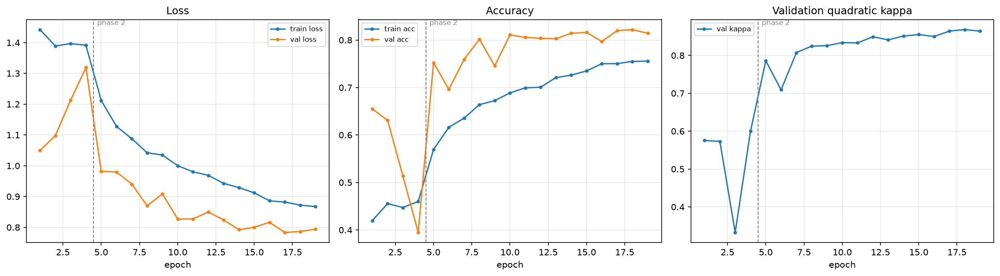

In [13]:
summary = json.loads((FINAL / "summary.json").read_text()) if (FINAL / "summary.json").exists() else None
if summary is None or summary.get("quick"):
    import final_report
    final_report.main()
    summary = json.loads((FINAL / "summary.json").read_text())
print(f"final model: {summary['run']} | {summary['arch']} | pipeline {summary['pipeline']} | "
      f"{summary['img_size']} px | TTA {summary['tta']}")
display(Image(str(FINAL / "training_curves.png"), width=1000))
# Train and validation move together; early stopping ends the run once validation kappa stalls.


## 8. Experiments

Every experiment changes one thing relative to the one before it, so each
difference has a single cause.

### 8a. First round (original data, v1 pipeline)


In [14]:
pd.read_csv("runs/tuning_table.csv")
# ResNet50 beat EfficientNet-B0; 256 px beat 224; the weighted sampler beat class weights;
# an ordinal regression head did not beat classification.


,run,architecture,head,image size,dropout,balancing,epochs,minutes,best val kappa
0,resnet50_256,resnet50,classification,256,0.3,sampler,24,40.4,0.9000
1,resnet50,resnet50,classification,224,0.3,sampler,15,21.8,0.8947
2,resnet50_ordinal,resnet50,regression,224,0.3,sampler,19,29.1,0.8816
3,effnetb0_256,efficientnet_b0,classification,256,0.3,sampler,28,35.0,0.8813
4,effnetb0_drop5,efficientnet_b0,classification,224,0.5,sampler,23,27.9,0.8671
5,effnetb0_sampler,efficientnet_b0,classification,224,0.3,sampler,16,18.3,0.8568
6,effnetb0_weights,efficientnet_b0,classification,224,0.3,weights,14,16.8,0.8134


### 8b. Domain shift and three fixes (original data)

The APTOS-only model scored 0.87 kappa at home but 0.59 on DDR (China).
Moving its decision points with a few hundred local photos helped a little;
fine-tuning on 1,000 DDR photos fixed DDR but made it forget APTOS
(catastrophic forgetting); training on both datasets fixed both.


test set,APTOS test,DDR test
model,,
"A: fine-tuned on 1,000 DDR",0.774,0.756
B: trained on APTOS + DDR,0.877,0.864
shipped (APTOS only),0.870,0.590


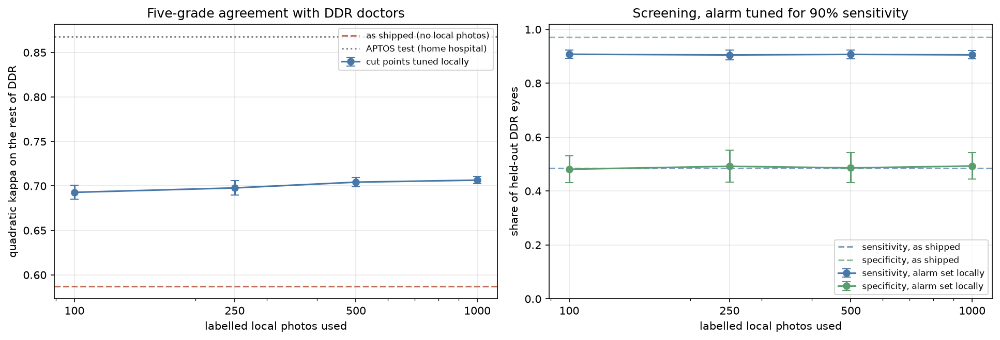

In [15]:
display(pd.read_csv("runs/domain_experiments/summary.csv").pivot(index="model", columns="test set", values="kappa").round(3))
display(Image("runs/local_calibration/local_calibration.png", width=950))


### 8c. Pipeline ablation on the cleaned data, all four hospitals


In [16]:
s = pd.read_csv(RUNS / "summary.csv")
order = ["r0_oldchain_256", "r1b_v2prep_v1aug_256", "r1_v2_256", "r2_v2_448", "s2_resnet_v3_448", "e2_resnet_v4_448",
         "c2_convnext_v3_448", "r3_v2_448_multi", "s3_resnet_v3_448_multi", "e3_resnet_v4_448_multi",
         "c3_convnext_v3_448_multi"]
what = {"r0_oldchain_256": "v1 chain, 256 px", "r1b_v2prep_v1aug_256": "drop enhancement",
        "r1_v2_256": "+ strong augmentation", "r2_v2_448": "+ 448 px", "s2_resnet_v3_448": "+ common outline (v3)",
        "e2_resnet_v4_448": "+ circle, edge, contrast (v4)", "c2_convnext_v3_448": "ConvNeXt, v3",
        "r3_v2_448_multi": "v2, + DDR", "s3_resnet_v3_448_multi": "v3, + DDR",
        "e3_resnet_v4_448_multi": "v4, + DDR", "c3_convnext_v3_448_multi": "ConvNeXt, v3, + DDR"}
k = s.pivot(index="run", columns="test set", values="kappa")
k = k.reindex([r for r in order if r in k.index])
k.insert(0, "change", [what[r] for r in k.index])
k[["change", "aptos", "ddr", "idrid", "messidor"]].round(3)
# APTOS-only runs never saw DDR, IDRiD or Messidor-2; pooled runs saw DDR only.


test set,change,aptos,ddr,idrid,messidor
run,,,,,
r0_oldchain_256,"v1 chain, 256 px",0.881,0.528,0.784,0.495
r1b_v2prep_v1aug_256,drop enhancement,0.883,0.573,0.676,0.536
r1_v2_256,+ strong augmentation,0.901,0.573,0.722,0.499
r2_v2_448,+ 448 px,0.884,0.625,0.751,0.584
s2_resnet_v3_448,+ common outline (v3),0.914,0.632,0.761,0.603
e2_resnet_v4_448,"+ circle, edge, contrast (v4)",0.874,0.541,0.765,0.531
c2_convnext_v3_448,"ConvNeXt, v3",0.874,0.620,0.777,0.606
r3_v2_448_multi,"v2, + DDR",0.899,0.880,0.745,0.634
s3_resnet_v3_448_multi,"v3, + DDR",0.892,0.864,0.811,0.629


**Reading the ablation.**

- **Resolution** (256 to 448 px) was the most consistent gain on unseen hospitals.
- **Dropping the enhancement** helped on three hospitals and hurt IDRiD.
- **The common outline** lifted the pooled model's IDRiD kappa from 0.745 to
  0.811 and its healthy-eye specificity there from 41 % to 63 %, confirming the
  shortcut, at no cost elsewhere.
- **Balanced pooling** gave the best unseen-hospital scores and fixed an earlier
  drop in proliferative recall caused by an unbalanced pool.

### 8d. Backbone decision, fixed before training

ConvNeXt-Tiny would replace ResNet50 only if it won on validation **and** was
not worse on the unseen hospitals or on severe and proliferative recall, the
urgent-referral grades. It won on validation (0.898 vs 0.868) and on Messidor-2,
tied IDRiD, but had lower severe/proliferative recall at three of four
hospitals, so ResNet50 was kept. This matches Fang et al. (2023): on APTOS,
architectures newer than about 2014 give little or no gain over ResNet-50.


In [17]:
r = pd.read_csv(RUNS / "per_grade_recall.csv", header=[0, 1], index_col=0)
pick = [c for c in r.columns if c[0] in ("s3_resnet_v3_448_multi", "c3_convnext_v3_448_multi")]
r[pick].rename(columns={"s3_resnet_v3_448_multi": "ResNet50", "c3_convnext_v3_448_multi": "ConvNeXt"}, level=0)


ResNet50                        ConvNeXt                       
                      aptos    ddr  idrid messidor    aptos    ddr  idrid messidor
0 No DR               0.952  0.934  0.625    0.808    0.968  0.926  0.555    0.789
1 Mild                0.608  0.383  0.700    0.250    0.686  0.447  0.800    0.367
2 Moderate            0.732  0.785  0.765    0.558    0.812  0.846  0.732    0.658
3 Severe              0.480  0.514  0.217    0.213    0.400  0.571  0.229    0.093
4 Proliferative DR    0.725  0.868  0.581    0.429    0.650  0.919  0.516    0.371

## 9. Final model evaluation

The final model's test photos were opened once, after every decision above had
been made on validation photos. Four-view test-time augmentation (the photo as
is, mirrored, flipped, and both, averaged) is used.


In [18]:
display(pd.read_csv(FINAL / "metrics.csv"))


,hospital,photos,accuracy,macro F1,quadratic kappa,sensitivity (any DR),specificity (any DR),ROC-AUC (any DR)
0,"APTOS (India, home)",504,0.8155,0.6881,0.8921,1.0000,0.9520,0.9932
1,DDR (China),1855,0.8394,0.6883,0.8640,0.8910,0.9336,0.9677
2,"IDRiD (India, other hospital, unseen)",446,0.5942,0.5295,0.8114,0.9937,0.6250,0.9457
3,"Messidor-2 (France, unseen)",1729,0.6403,0.4720,0.6289,0.7304,0.8085,0.8399


In [19]:
for n in DATASETS:
    print(LABEL[n]); display(pd.read_csv(FINAL / f"per_class_{n}.csv", index_col=0))
# Precision: of the photos called grade g, how many were. Recall: of the real grade-g photos, how many were caught.


APTOS 2019 (India)


,precision,recall,f1-score,support
0 No DR,1.0000,0.9520,0.9754,250.0
1 Mild,0.5254,0.6078,0.5636,51.0
2 Moderate,0.7319,0.7319,0.7319,138.0
3 Severe,0.4615,0.4800,0.4706,25.0
4 Proliferative DR,0.6744,0.7250,0.6988,40.0
macro avg,0.6787,0.6993,0.6881,504.0
weighted avg,0.8260,0.8155,0.8201,504.0


DDR (China)


,precision,recall,f1-score,support
0 No DR,0.8938,0.9336,0.9133,919.0
1 Mild,0.3711,0.3830,0.3770,94.0
2 Moderate,0.8625,0.7854,0.8222,671.0
3 Severe,0.5000,0.5143,0.5070,35.0
4 Proliferative DR,0.7815,0.8676,0.8223,136.0
macro avg,0.6818,0.6968,0.6883,1855.0
weighted avg,0.8403,0.8394,0.8388,1855.0


IDRiD (India, other hospital)


,precision,recall,f1-score,support
0 No DR,0.9756,0.6250,0.7619,128.0
1 Mild,0.1609,0.7000,0.2617,20.0
2 Moderate,0.6062,0.7647,0.6763,153.0
3 Severe,0.5455,0.2169,0.3103,83.0
4 Proliferative DR,0.7059,0.5806,0.6372,62.0
macro avg,0.5988,0.5774,0.5295,446.0
weighted avg,0.6948,0.5942,0.6087,446.0


Messidor-2 (France)


,precision,recall,f1-score,support
0 No DR,0.8093,0.8085,0.8089,1013.0
1 Mild,0.2705,0.2500,0.2598,264.0
2 Moderate,0.4526,0.5585,0.5000,342.0
3 Severe,0.8000,0.2133,0.3368,75.0
4 Proliferative DR,0.4839,0.4286,0.4545,35.0
macro avg,0.5633,0.4518,0.4720,1729.0
weighted avg,0.6495,0.6403,0.6363,1729.0


APTOS 2019 (India)


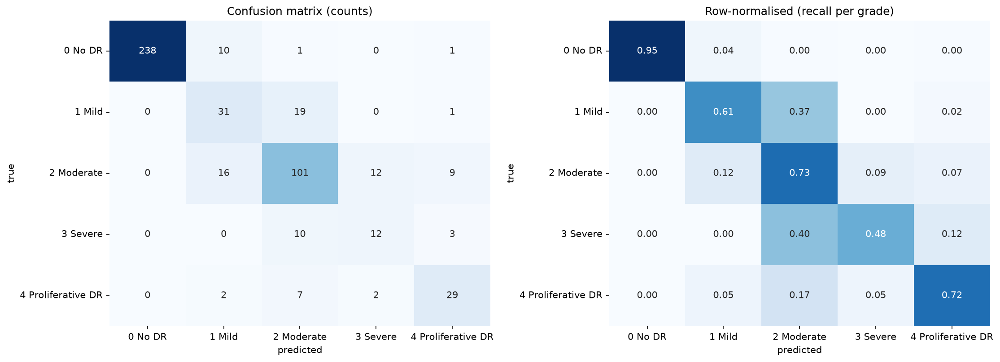

DDR (China)


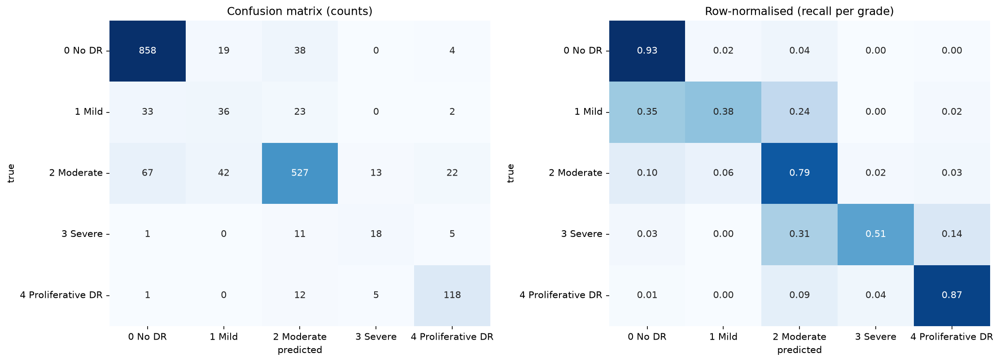

IDRiD (India, other hospital)


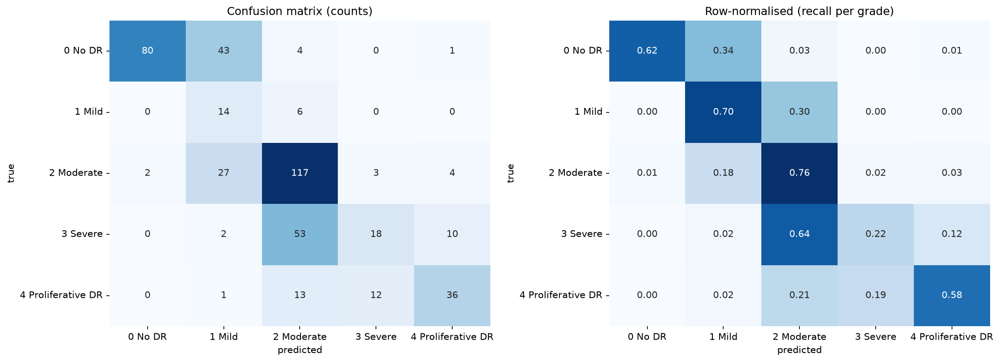

Messidor-2 (France)


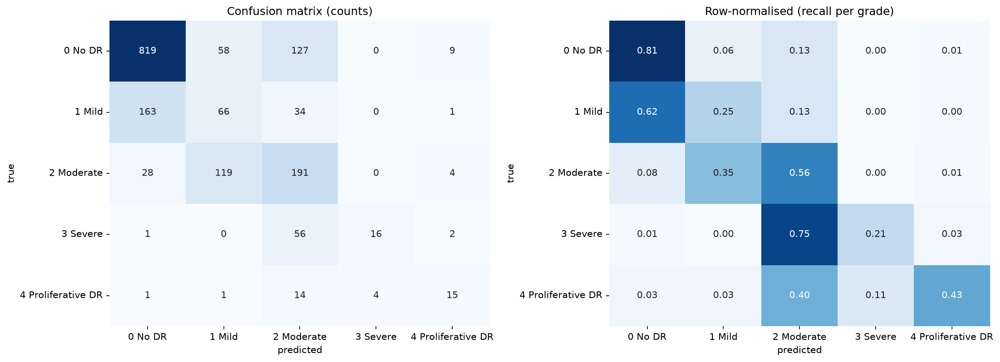

In [20]:
for n in DATASETS:
    print(LABEL[n]); display(Image(str(FINAL / f"confusion_{n}.png"), width=1000))
# Most errors sit next to the diagonal: neighbouring grades, the disagreement clinicians also have.


**Explainability.** Grad-CAM traces each prediction back to the pixels that drove
it; correct predictions, near misses and gross errors are shown. Heat on lesions
is reassuring; heat on the border would indicate a shortcut. It shows
correlation, not clinical reasoning.


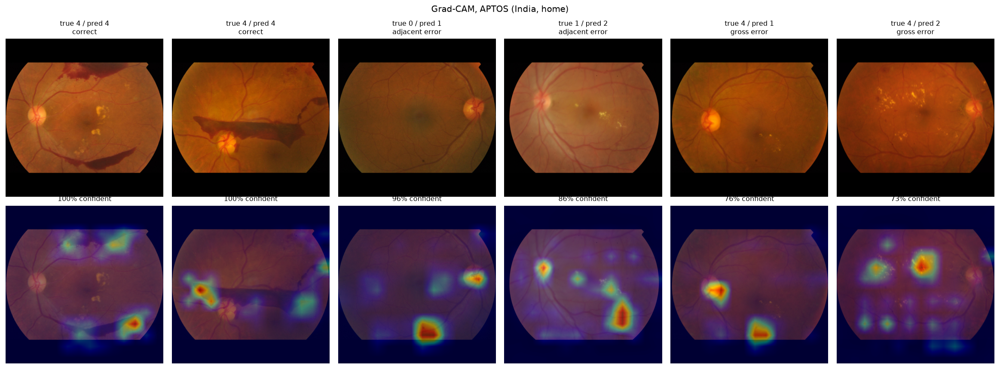

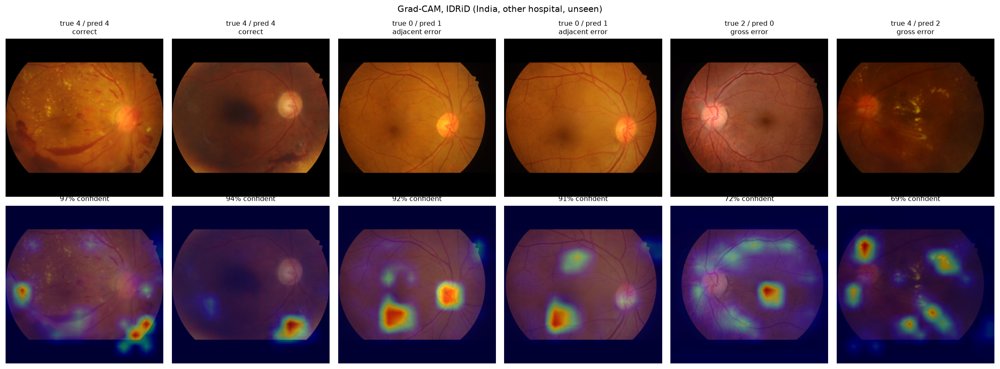

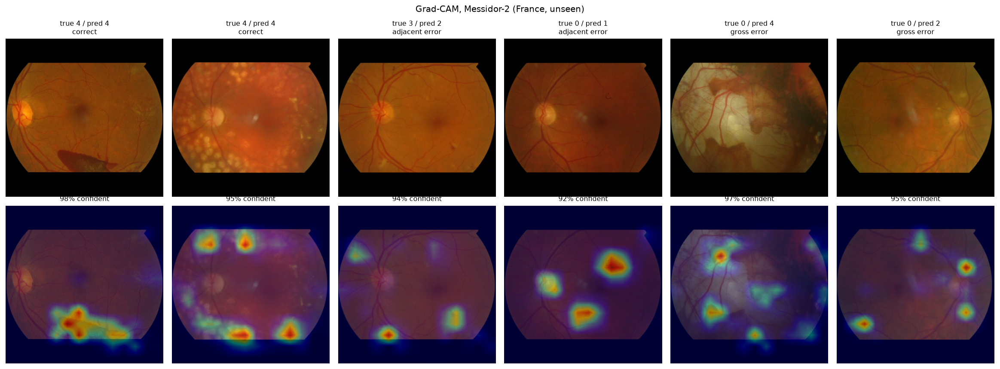

In [21]:
for n in ("aptos", "idrid", "messidor"):
    display(Image(str(FINAL / f"gradcam_{n}.png"), width=1100))


## 10. The prototype

```
.venv/bin/python app.py
```

opens `http://127.0.0.1:7860`. Upload a fundus photo; the page applies exactly
the preprocessing the model was trained with, then shows the five stage
probabilities, the preprocessed photo, the Grad-CAM heatmap and a verdict.
It refuses to sound certain: below 50 % confidence it says "uncertain, refer to
a specialist", and a 20 % or greater chance of severe or proliferative disease
adds an urgent-referral alert. Sample photos with known grades are in
`sample_images/`.


## 11. Discussion

**Healthcare impact.** Screening capacity is limited by graders, not cameras. A
model that clears clearly healthy eyes and flags the rest would let specialists
spend their time on the patients who need them. For that use, sensitivity to
referable disease matters most, and the final model misses very few diseased
eyes at the hospitals it trained on.

**Deployment feasibility.** The model is about 95 MB and grades a photo in well
under a second on a laptop, so compute is not the barrier. Regulatory approval,
image-quality control at capture and, above all, **local validation** are: our
own results show a model can score at published levels at home and degrade at
an unseen hospital.

**Limitations.**

- Scores drop at unseen hospitals (domain shift), most at Messidor-2, whose
  Kaggle copy is downsized to 512 px and graded by the strictest protocol.
- Labels are noisy: identical photos were graded differently.
- Grades 3 and 4 have 25-75 test photos per hospital, so their per-grade
  numbers are uncertain.
- The model still over-calls some healthy IDRiD eyes.
- Grad-CAM shows where the model looked, not why.

**Future work.** Pretrain on more hospitals; a retina-specific foundation model
such as RETFound-Green; an ensemble of ResNet50 and ConvNeXt, whose strengths
were complementary; an image-quality gate that rejects ungradable photos; and
calibrating the decision thresholds at each new clinic.
